In [175]:
import pandas as pd

caminho = 'tabelas/natura_criativos_bq-results-20250919-232914-1758324569191.csv'

natura = pd.read_csv(caminho, low_memory=False)

natura.columns

Index(['Plataforma', 'campaign_id', 'campaign_name', 'adset_id', 'adset_name',
       'ad_id', 'ad_name', 'placement', 'keyword', 'insertion_order_id',
       'insertion_order_name', 'insertion_order_name_orig', 'criativo', 'date',
       'imagem_anuncio', 'texto_anuncio', 'link_anuncio', 'origem_fluxo',
       'campaign_name_orig', 'adset_name_orig', 'ad_name_orig', 'cost',
       'cost_revenue', 'impressions', 'video_views', 'video_quartile_25_views',
       'video_quartile_50_views', 'video_quartile_75_views',
       'video_completions', 'reactions', 'comments', 'shares', 'post_saves',
       'engagements', 'total_engagements', 'clicks', 'link_clicks',
       'visitas_qualificadas', 'sessions', 'new_users', 'pageviews', 'users',
       'user_permanence_10s', 'user_permanence_20s', 'add_to_cart', 'revenue',
       'bounces', 'transactions', 'impressions_viewable', 'marca', 'pais',
       'operacao', 'categoria', 'submarca', 'objetivo_de_comunicacao',
       'formato_campanha', 'free_

In [176]:
natura_1 = natura.copy()

# natura_1 = natura_1[natura_1['objetivo_de_midia'] == 'conversao']
# natura_1 = natura_1[natura_1['objetivo_de_comunicacao'] == 'conversao']
# natura_1 = natura_1[natura_1['adfront'] == 'banner']
natura_1 = natura_1[natura_1['cost'] >= 100]
# natura_1 = natura_1[natura_1['tipo_de_ativacao'] == 'ad-sequence']

# print(natura_1['Plataforma'].unique()) ##Pode tirar
# print(natura_1['placement'].unique()) ##Pode tirar
# print(natura_1['keyword'].unique()) #Pode tirar
# print(natura_1['insertion_order_id'].unique()) ##Pode tirar
# print(natura_1['insertion_order_name'].unique()) ##Pode tirar
# print(natura_1['insertion_order_name_orig'].unique()) ##Pode tirar
# print(natura_1['criativo'].unique()) ##Pode tirar
# print(natura_1['origem_fluxo'].unique()) ##Pode tirar
print(natura_1['objetivo_de_comunicacao'].unique())
# print(natura_1['formato_campanha'].unique()) ##Pode tirar
print(natura_1['objetivo_de_midia'].unique())
print(natura_1['tipo_de_ativacao'].unique())
# print(natura_1['tipo_keyword'].unique()) ##Pode tirar
print(natura_1['estrategia'].unique())
print(natura_1['segmentacao'].unique())
print(natura_1['faixa_etaria'].unique())
print(natura_1['praca'].unique())
print(natura_1['adfront'].unique())
# print(natura_1['formato'].unique())
print(natura_1['precision_mkt'].unique())
print(natura_1['dimensao'].unique())
print(natura_1['skippable'].unique())
print(natura_1['pilar'].unique())
print(natura_1['acao_influ'].unique())
print(natura_1['veiculacao'].unique())
print(natura_1['status_anuncio'].unique())

print(natura_1['ad_name'].unique())

natura_1.shape


['conversao' 'consideracao' 'awareness' 'Taxonomia errada']
['conversao' 'visitas' 'alcance' 'views' 'trafego' 'leads']
['Taxonomia errada' 'open-auction' 'merchan' 'leilao' 'reach-frequency'
 'ad-sequence']
['rmkt' 'lookalike' 'amplo' 'geo' 'affinity' 'interes' 'imkt'
 'custom-affinity']
['carr' 'amplo' 'bases' 'cp-perf' 'interes' 'cp' 'cp-corpo'
 'rmkt-engajados-ig' 'rmkt-campanhas-anteriores'
 'lal-campanhas-anteriores' 'cp-make' 'dat-pres' 'lal-awareness'
 'cp-cabelo' 'interac' 'videos' 'compr' 'pagev' 'site' 'musica' 'entr'
 'ctp' 'cla-int' 'nam-est' 'ver-ref' 'nam-pre' 'est' 'cp-rosto'
 'rmkt-awareness']
['amplo' '30-45' '30mais' '25-55' '25-45' '18mais' '18-30' '18-45' '25-34'
 '35mais' 'Taxonomia errada' '25mais' '35-55' '18-54' '30-55' '18-29'
 '45mais']
['nac' 'df' 'pracas-prioritarias' 'sp' 'rj' 'pr' 'mg' 'salvador' 'pa'
 'Taxonomia errada' 'fortaleza' 'florianopolis' 'ne' 'recife' 'go' 'natal'
 'ribeirao-preto' 'pe' 'al' 'joao-pessoa' 'n' 'campinas' 'belo-horizonte']
['cata

(65209, 91)

In [177]:
natura_1 = natura_1[['objetivo_de_comunicacao', 'objetivo_de_midia', 'tipo_de_ativacao', 'estrategia', 'adfront' \
                 , 'ad_id', 'ad_name', 'campaign_id', 'imagem_anuncio', 'ad_name', 'cost', 'impressions', 'clicks']]

natura_1 = natura_1.loc[:, ~natura_1.columns.duplicated()]
natura_1.shape

(65209, 12)

In [178]:
natura_agrupado = natura_1.copy()

natura_agrupado = natura_agrupado.groupby(['campaign_id', 'imagem_anuncio', 'ad_name', 'objetivo_de_comunicacao', \
                                       'objetivo_de_midia', 'tipo_de_ativacao', 'estrategia', 'adfront']).agg(
    {
        'cost':'sum',
        'impressions': 'sum',
        'clicks': 'sum'
    }
).reset_index()

natura_agrupado['clicksper1000impression'] = 1000*natura_agrupado['clicks']/natura_agrupado['impressions']
natura_agrupado['cpc'] = natura_agrupado['cost']/natura_agrupado['clicks']
natura_agrupado['cpm'] = 1000*natura_agrupado['cost']/natura_agrupado['impressions']
natura_agrupado['imagem_anuncio'] = natura_agrupado['imagem_anuncio'].str.split('/').str[-1]
natura_agrupado['ad_name'] = natura_agrupado['ad_name'].str.split('/').str[-1]

natura_agrupado.head(20)
#natura_agrupado.shape

,campaign_id,imagem_anuncio,ad_name,objetivo_de_comunicacao,objetivo_de_midia,tipo_de_ativacao,estrategia,adfront,cost,impressions,clicks,clicksper1000impression,cpc,cpm
0,6554843543977,1456237089384385304.jpg,na_na_banner_carrossel_1080x1080_na_na_conceit...,awareness,alcance,leilao,interes,banner,2241.443672,1900862.0,3430.0,1.804445,0.653482,1.179172
1,6554843543977,1811777033439179539.jpg,na_na_video_posic-automatico_na_6s_skip-v_ambo...,awareness,alcance,leilao,interes,video,476.298073,400888.0,280.0,0.698449,1.701065,1.188108
2,6554843543977,1811777033439179539.jpg,na_na_video_video_na_6s_skip-v_ambos_na_na_na_...,awareness,alcance,leilao,rmkt,video,113.691109,72520.0,55.0,0.758411,2.067111,1.567721
3,6554843543977,1858833709586577921.png,na_na_banner_link-ad_1080x1080_na_na_ambos_na_...,awareness,alcance,leilao,geo,banner,9443.939877,1726197.0,4172.0,2.416874,2.263648,5.470951
4,6554843543977,4643315255528295625.png,na_na_banner_link-ad_1080x1080_na_na_conceito_...,awareness,alcance,leilao,interes,banner,9900.546237,8412285.0,17946.0,2.133309,0.551685,1.176915
5,6554843543977,4643315255528295625.png,na_na_banner_link-ad_1080x1080_na_na_conceito_...,awareness,alcance,leilao,rmkt,banner,6571.505147,4278574.0,8266.0,1.931952,0.795004,1.535910
6,6554843543977,5923611742530770112.png,na_na_banner_link-ad_1080x1080_na_na_ambos_na_...,awareness,alcance,leilao,geo,banner,1964.542983,135128.0,615.0,4.551240,3.194379,14.538386
7,6554843543977,6367794708270278352.jpg,na_na_video_posic-automatico_na_6s_skip-v_ambo...,awareness,alcance,leilao,rmkt,video,4524.447042,2791626.0,3333.0,1.193928,1.357470,1.620721
8,6554843543977,6367794708270278352.jpg,na_na_video_video_na_6s_skip-v_ambos_na_na_na_...,awareness,alcance,leilao,interes,video,2587.602424,2145974.0,2314.0,1.078298,1.118238,1.205794
9,6554843543977,7135954606256484472.png,na_na_banner_link-ad_1080x1080_na_na_ambos_na_...,awareness,alcance,leilao,rmkt,banner,4622.306670,3097629.0,4586.0,1.480487,1.007917,1.492208


In [179]:
verificado = natura_agrupado.copy()

print(len(verificado['campaign_id'].unique()))

verificado = verificado[['campaign_id', 'objetivo_de_comunicacao', \
                            'objetivo_de_midia', 'tipo_de_ativacao', 'estrategia', 'adfront']].drop_duplicates()

print(verificado.shape)

print(verificado.groupby('campaign_id')['campaign_id'].count().nlargest(5))

print(natura_agrupado[natura_agrupado['campaign_id'] == 6559218408977])

155
(382, 6)
campaign_id
6559218408977    6
6562148677577    6
6565890789777    6
6566078064377    6
6571141217977    6
Name: campaign_id, dtype: int64
      campaign_id           imagem_anuncio  \
40  6559218408977  1063506343076874149.jpg   
41  6559218408977  1204820944565906699.jpg   
42  6559218408977  1967325226668984022.jpg   
43  6559218408977  2525741242387248400.jpg   
44  6559218408977  3723590268336876822.jpg   
45  6559218408977   404830735047707084.jpg   
46  6559218408977  4052278357474770190.jpg   
47  6559218408977  4652182023766061360.jpg   
48  6559218408977  4895075964518569011.jpg   
49  6559218408977  5133095922664685815.jpg   
50  6559218408977  5486118761187703963.jpg   
51  6559218408977  5599021174698104997.jpg   
52  6559218408977  5626172674406265397.jpg   
53  6559218408977  5811991939722818359.jpg   
54  6559218408977   666874790879086791.jpg   
55  6559218408977  8799861968379015986.jpg   
56  6559218408977  9426308022359451328.jpg   

                   

In [180]:
# 1. Carrega o arquivo usando a orientação de índice
# Isso transforma as chaves principais (nomes dos arquivos) em linhas
df_imagem = pd.read_json('resultados_ia.json', orient='index')

# 2. (Opcional) O nome do arquivo estará no índice (index) do DataFrame.
# Se você quiser transformar o nome do arquivo em uma coluna normal:
df_imagem = df_imagem.reset_index().rename(columns={'index': 'arquivo'})
df_imagem = df_imagem[['arquivo', 'brainai_index', 'focus_index', 'cognitive_demand_index']]

# Exibe o resultado
print(df_imagem.head())

                   arquivo  brainai_index  focus_index  cognitive_demand_index
0  8572474697454358902.jpg      85.466591     7.835850               85.647281
1  4187168035276168277.jpg      73.444573     8.626669               67.825190
2  6119720837473432976.png      65.899812     8.845279               51.455920
3  4300327416286945370.jpg      39.847908    64.721964               32.503734
4  2782306428767059128.png      86.968133     9.553435               74.676456


In [181]:
df_final = pd.merge(
    natura_agrupado,
    df_imagem,
    left_on='imagem_anuncio',    # Coluna do df_esquerda
    right_on='arquivo',    # Coluna do df_direita
    how='inner'
)

df_final = df_final.drop(columns='arquivo')

print(df_final.sort_values(ascending=False, by = 'clicksper1000impression').head())

             campaign_id           imagem_anuncio  \
1791  120213399492750371  3769406842967649280.png   
921        6716389278577  2289902062643959692.jpg   
924        6716389278577  5026844426935601008.jpg   
141        6565890789777  5821355621198753491.jpg   
2095  120223114976570625  8193908718208255182.jpg   

                                                ad_name  \
1791  institucional_institucional_banner_feed_na_na_...   
921   na_na_video_posic-automatico_na_15s_skip-v_amb...   
924   na_na_video_posic-automatico_na_45s_skip-v_amb...   
141   na_na_video_posic-automatico_na_30s_skip-v_con...   
2095  na_na_video_posic-automatico_na_6s_skip-v_ambo...   

     objetivo_de_comunicacao objetivo_de_midia  tipo_de_ativacao estrategia  \
1791               conversao         conversao  Taxonomia errada       rmkt   
921             consideracao             views            leilao      amplo   
924             consideracao             views            leilao      amplo   
141       

In [182]:
# 1. Calcula a matriz de correlação completa entre todas as variáveis
# Por padrão, usa o método Pearson.
matriz_correlacao = df_final[['cost', 'brainai_index', 'focus_index', 'cognitive_demand_index', 'clicksper1000impression']].corr()

# 2. Isola a coluna da variável resposta ('clicksperimpression')
# Esta Series agora contém a correlação de cada feature com a variável resposta.
correlacao_com_resposta = matriz_correlacao['clicksper1000impression']

# 3. (Opcional) Ordena os valores para ver o ranking das features
# Usamos .drop() para remover a autocorrelação (1.0)
correlacao_ordenada = correlacao_com_resposta.drop('clicksper1000impression').sort_values(ascending=False)

print("--- Correlação das Features com clicksperimpression ---")
print(correlacao_ordenada)

--- Correlação das Features com clicksperimpression ---
focus_index               0.074000
cost                     -0.030406
brainai_index            -0.099532
cognitive_demand_index   -0.127126
Name: clicksper1000impression, dtype: float64


In [183]:
# 1. Filtro inicial: Remover campanhas com apenas 1 imagem
# Contamos quantas imagens tem por campanha
contagem = df_final.groupby('campaign_id')['imagem_anuncio'].transform('count')
df_filtered = df_final[contagem > 1].copy()

# 2. O Self-Join (O segredo da combinação 2 a 2)
# Cruzamos o dataframe com ele mesmo usando o campaign_id como chave
df_comb = pd.merge(df_filtered, df_filtered, on='campaign_id', suffixes=('1', '2'))

# 3. Filtro para não repetir combinações e não comparar a imagem com ela mesma
# A lógica: Pegamos apenas onde o nome da imagem 1 é "menor" (alfabeticamente) que a imagem 2.
# Isso garante que teremos (A vs B), mas remove (B vs A) e (A vs A).
df_comb = df_comb[df_comb['imagem_anuncio1'] < df_comb['imagem_anuncio2']]

# 4. Cálculo das Variações (Diferença entre Imagem 1 e Imagem 2)
# Se o resultado for positivo, a imagem 1 tinha um índice maior.
df_comb['delta_brainai'] = df_comb['brainai_index1'] - df_comb['brainai_index2']
df_comb['delta_cognitive'] = df_comb['cognitive_demand_index1'] - df_comb['cognitive_demand_index2']
df_comb['delta_focus'] = df_comb['focus_index1'] - df_comb['focus_index2']

# 5. Definição do Vencedor (Lógica Binária)
# 1 se a Imagem 1 tiver mais clicks/1000, 0 caso contrário (ou seja, a Imagem 2 ganhou)
df_comb['vencedor'] = (df_comb['clicksper1000impression1'] > df_comb['clicksper1000impression2']).astype(int)

# 6. Seleção e Renomeação final das colunas
colunas_finais = [
    'campaign_id',
    'imagem_anuncio1', 'imagem_anuncio2',
    'ad_name1', 'ad_name2',
    'objetivo_de_comunicacao1', 'objetivo_de_comunicacao2',
    'objetivo_de_midia1', 'objetivo_de_midia2',
    'tipo_de_ativacao1', 'tipo_de_ativacao2',
    'estrategia1', 'estrategia2',
    'adfront1', 'adfront2',
    'delta_brainai',         # Variação BrainAI
    'delta_cognitive',       # Variação Cognitive Demand
    'delta_focus',           # Variação Focus
    'vencedor'               # Target (1 = Imagem1 ganhou, 0 = Imagem2 ganhou)
]

df_final = df_comb[colunas_finais]
# df_final = df_final[df_final['objetivo_de_comunicacao1'] == df_final['objetivo_de_comunicacao2']]
# df_final = df_final[df_final['objetivo_de_comunicacao1'] == 'conversao']
# df_final = df_final[df_final['objetivo_de_midia1'] == df_final['objetivo_de_midia2']]
# df_final = df_final[df_final['objetivo_de_midia1'] == 'conversao']
# df_final = df_final[df_final['tipo_de_ativacao1'] != 'Taxonomia errada']
# df_final = df_final[df_final['estrategia1'] == 'lookalike']
# df_final = df_final[df_final['adfront1'] == 'banner']

# Exibir resultado
print(f"Total de pares gerados: {len(df_final)}")
df_final.head()

df_final.to_csv('natura_agrupado.csv', sep = ';', decimal=',')

Total de pares gerados: 63760


In [184]:
print(df_final['tipo_de_ativacao1'].unique())
print(df_final['estrategia1'].unique())
print(df_final['adfront1'].unique())

['leilao' 'reach-frequency' 'Taxonomia errada' 'merchan' 'open-auction'
 'ad-sequence']
['interes' 'rmkt' 'geo' 'lookalike' 'amplo' 'imkt' 'affinity']
['banner' 'video' 'catalogo' 'dinamico']


In [185]:
# 1. Calcula a matriz de correlação completa entre todas as variáveis
# Por padrão, usa o método Pearson.
matriz_correlacao = df_final[['delta_brainai', 'delta_cognitive', 'delta_cognitive', 'vencedor']].corr()

# 2. Isola a coluna da variável resposta ('clicksperimpression')
# Esta Series agora contém a correlação de cada feature com a variável resposta.
correlacao_com_resposta = matriz_correlacao['vencedor']

# 3. (Opcional) Ordena os valores para ver o ranking das features
# Usamos .drop() para remover a autocorrelação (1.0)
correlacao_ordenada = correlacao_com_resposta.drop('vencedor').sort_values(ascending=False)

print("--- Correlação das Features com vencedor ---")
print(correlacao_ordenada)

--- Correlação das Features com vencedor ---
delta_cognitive   -0.030860
delta_cognitive   -0.030860
delta_brainai     -0.035497
Name: vencedor, dtype: float64


In [186]:
from sklearn.model_selection import train_test_split

X = df_final[['delta_brainai', 'delta_cognitive', 'delta_focus']]#, 'cost', 'brainai_index', 'focus_index', 'cognitive_demand_index']]
# X = pd.get_dummies(
#     X, 
#     columns=['brand', 'channel', 'buy'],  # 1. Escolhe SÓ as colunas que você quer converter
#     drop_first=True,      # 3. Remove a primeira coluna para evitar redundância*
#     dtype=int             # 4. Força sair 0 e 1
# )

print(X.columns)

y = df_final['vencedor']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42 # Para garantir que a divisão seja a mesma sempre
)

print(X.head(5))
print('-'*60)
print(y.head(5))

Index(['delta_brainai', 'delta_cognitive', 'delta_focus'], dtype='object')
   delta_brainai  delta_cognitive  delta_focus
1      -9.054355        -2.390737    -7.231743
2      -9.054355        -2.390737    -7.231743
3      -6.493190        12.898039     0.082489
4      -6.282829         0.860736    -2.354977
5      -6.282829         0.860736    -2.354977
------------------------------------------------------------
1    1
2    1
3    0
4    0
5    0
Name: vencedor, dtype: int64


In [187]:
from sklearn.tree import DecisionTreeClassifier

# 1. Cria o modelo (Decision Tree Regressor)
# Definimos uma profundidade máxima (max_depth) de 5. 
# Profundidades pequenas garantem interpretabilidade.
arvore = DecisionTreeClassifier(
    max_depth=4, 
    random_state=42
)

# 2. Treina o modelo
print("Iniciando o treinamento do Decision Tree Regressor...")
arvore.fit(X_train, y_train)
print("Treinamento concluído.")

# 3. Faz previsões no conjunto de teste
y_pred = arvore.predict(X_test)

Iniciando o treinamento do Decision Tree Regressor...
Treinamento concluído.


Acurácia Geral: 60.41%
------------------------------
              precision    recall  f1-score   support

           0       0.60      0.95      0.73      7367
           1       0.66      0.13      0.22      5385

    accuracy                           0.60     12752
   macro avg       0.63      0.54      0.48     12752
weighted avg       0.62      0.60      0.52     12752



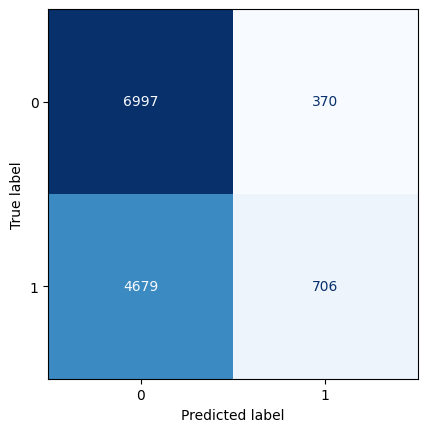

In [188]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Faça as previsões no seu conjunto de TESTE (dados que o modelo nunca viu)
y_pred = arvore.predict(X_test)

# 2. Calcule a Acurácia Geral
# (Percentual de acertos)
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia Geral: {acc:.2%}")
print("-" * 30)

# 3. Veja o Relatório de Classificação (O MAIS IMPORTANTE)
# Mostra a performance para CADA classe
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    cmap='Blues',
    colorbar=False
)

plt.show()

In [189]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extrai a importância das features
importances = arvore.feature_importances_

# 2. Cria um DataFrame para facilitar a visualização
# X_train.columns contém os nomes das features
feature_importances_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# 3. Ordena pela importância decrescente
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Exibe o resultado
print(feature_importances_df)

           Feature  Importance
2      delta_focus    0.461575
0    delta_brainai    0.355154
1  delta_cognitive    0.183271


In [190]:
import xgboost as xgb

# 1. Cria o modelo (XGBoost Regressor)
bostao = xgb.XGBClassifier(
    objective='binary:logistic', # Objetivo para regressão com erro quadrático
    n_estimators=200,             # Aumentamos o número de árvores para melhor performance
    learning_rate=0.05,           # Taxa de aprendizado
    max_depth=5,                  # Profundidade máxima de cada árvore
    random_state=42,
    n_jobs=-1                     # Usa todos os cores da CPU
)

# 2. Treina o modelo
print("Iniciando o treinamento do XGBoost Regressor...")
bostao.fit(X_train, y_train)
print("Treinamento concluído.")

Iniciando o treinamento do XGBoost Regressor...
Treinamento concluído.


Acurácia Geral: 69.64%
------------------------------
              precision    recall  f1-score   support

           0       0.70      0.84      0.76      7367
           1       0.69      0.50      0.58      5385

    accuracy                           0.70     12752
   macro avg       0.70      0.67      0.67     12752
weighted avg       0.70      0.70      0.69     12752



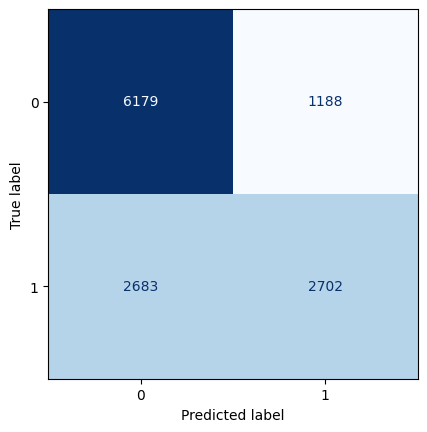

In [191]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Faça as previsões no seu conjunto de TESTE (dados que o modelo nunca viu)
y_pred = bostao.predict(X_test)

# 2. Calcule a Acurácia Geral
# (Percentual de acertos)
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia Geral: {acc:.2%}")
print("-" * 30)

# 3. Veja o Relatório de Classificação (O MAIS IMPORTANTE)
# Mostra a performance para CADA classe
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    cmap='Blues',
    colorbar=False
)

plt.show()

In [192]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extrai a importância das features
importances = bostao.feature_importances_

# 2. Cria um DataFrame para facilitar a visualização
# X_train.columns contém os nomes das features
feature_importances_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# 3. Ordena pela importância decrescente
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Exibe o resultado
print(feature_importances_df)

           Feature  Importance
2      delta_focus    0.366632
0    delta_brainai    0.338959
1  delta_cognitive    0.294408
